# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [1]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [3]:
from torchvision import models, transforms

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns
import numpy as np
import pandas as pd

In [6]:
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path

In [7]:
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 0. Build Datasets


In [8]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.build_dataset"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 22345: character maps to <undefined>


Tip: set HF_TOKEN env var for higher download rates from HuggingFace
Classified 10,411 products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\raw\manifest.csv
Downloaded 1126/1130 new images

Download summary:
  skincare: 7349
  haircare: 2322
  makeup: 740

Total: 10411 images



In [9]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.collect_unlabeled"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Exception in thread Thread-6 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\linet\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 29149: character maps to <undefined>


Tip: set HF_TOKEN env var for higher download rates from HuggingFace
Found 47,916 unlabeled products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\unlabeled\unlabeled_manifest.csv
Downloaded 47902/47916 unlabeled images

Total unlabeled images available: 47902



## 1. Load Datasets

Train: 7367 | Val: 1578 | Test: 1578
Classes: ['haircare', 'makeup', 'skincare']
haircare: 1687
makeup: 516
skincare: 5164


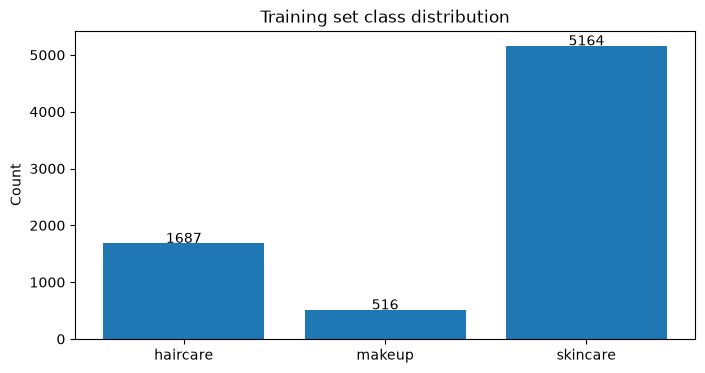

In [12]:
DATA_DIR = Path.cwd().parent / "data" / "raw"

train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
for cls, cnt in zip(train_ds.classes, counts):
    print(f"{cls}: {cnt}")
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [13]:
from classifier.train import train_model

model, history, best_acc = train_model(
    train_ds, val_ds, DEVICE,
    epochs=20,
    unfreeze_layers=14,
)
print(f"\nBest validation accuracy: {best_acc:.2f}%")

Train: 7367 | Val: 1578 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 231/231 [00:32<00:00,  7.04it/s]


  Loss: 0.8721 / 0.9397 | Val Acc: 51.90% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 231/231 [00:26<00:00,  8.72it/s]


  Loss: 0.7390 / 0.8026 | Val Acc: 67.74% | LR: 1.00e-04


...

  Loss: 0.5305 / 0.7972 | Val Acc: 67.36% | LR: 1.00e-04


Epoch 11/20: 100%|██████████| 231/231 [00:25<00:00,  8.93it/s]


  Loss: 0.5124 / 0.9626 | Val Acc: 61.41% | LR: 5.00e-05


Epoch 12/20: 100%|██████████| 231/231 [00:25<00:00,  8.96it/s]


  Loss: 0.4924 / 0.7913 | Val Acc: 70.09% | LR: 5.00e-05
  Early stopping triggered (no improvement for 5 epochs)

Best validation accuracy: 71.48%


## 3. Training Curves

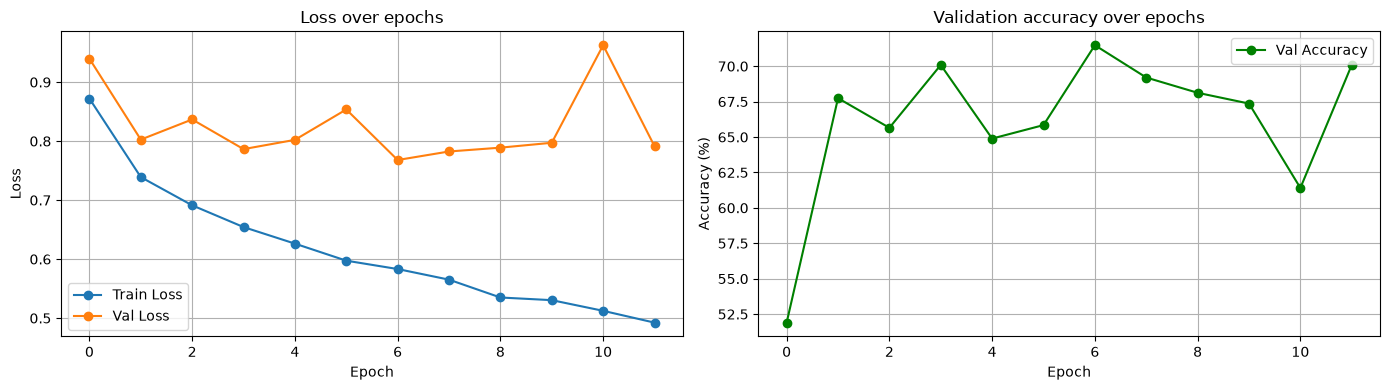

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

Testing: 100%|██████████| 50/50 [00:13<00:00,  3.80it/s]


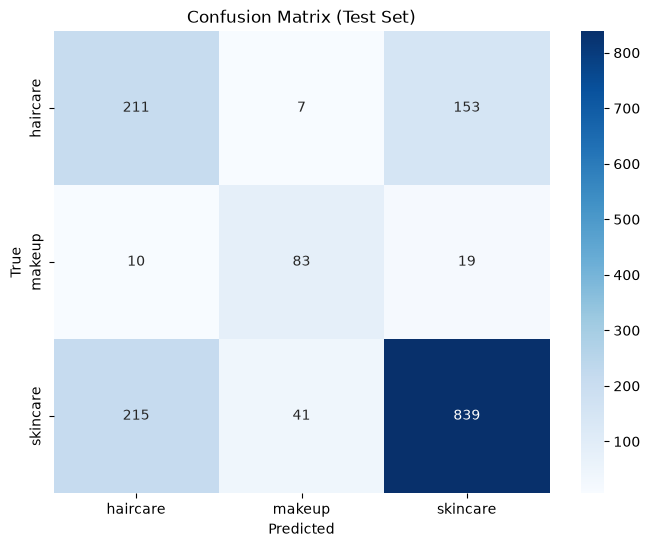

              precision    recall  f1-score   support

    haircare       0.48      0.57      0.52       371
      makeup       0.63      0.74      0.68       112
    skincare       0.83      0.77      0.80      1095

    accuracy                           0.72      1578
   macro avg       0.65      0.69      0.67      1578
weighted avg       0.73      0.72      0.72      1578



In [15]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Pseudo-label Unlabeled Images


In [16]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.pseudo_label"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Using device: cuda
Loaded model from C:\Projects\cosmetic-expiry-scanner\backend\data\models\resnet50_product_category.pt
Found 47,902 unlabeled images

Pseudo-labels above threshold (0.95): 4535
  haircare: 4382
  makeup: 98
  skincare: 55

Confidence stats:
  Mean: 0.9783
  Min:  0.9500
  Max:  1.0000

Copied 4535 pseudo-labeled images to C:\Projects\cosmetic-expiry-scanner\backend\data\raw

Dataset size now:
  haircare: 6816
  makeup: 839
  skincare: 7403
  Total: 15058
  (includes 4535 newly added pseudo-labels)



## 6. Retrain with Pseudo-Labeled Data


In [17]:
train_ds2 = ProductDataset(DATA_DIR, split='train')
val_ds2   = ProductDataset(DATA_DIR, split='val')
test_ds2  = ProductDataset(DATA_DIR, split='test')
test_loader2 = DataLoader(test_ds2, 32, shuffle=False)
total_train = len(train_ds2)
total_val = len(val_ds2)
total_test = len(test_ds2)
print('Train:', total_train, 'Val:', total_val, 'Test:', total_test)
print('Classes:', train_ds2.classes)
model2, history2, best_acc2 = train_model(train_ds2, val_ds2, DEVICE, epochs=20, unfreeze_layers=14)
print('Best validation accuracy:', best_acc2)

Train: 10542 Val: 2258 Test: 2258
Classes: ['haircare', 'makeup', 'skincare']
Train: 10542 | Val: 2258 | Classes: ['haircare', 'makeup', 'skincare']


Epoch 1/20: 100%|██████████| 330/330 [00:32<00:00, 10.06it/s]


  Loss: 0.7777 / 0.7093 | Val Acc: 75.07% | LR: 1.00e-04


Epoch 2/20: 100%|██████████| 330/330 [00:31<00:00, 10.44it/s]


  Loss: 0.6648 / 0.7163 | Val Acc: 74.89% | LR: 1.00e-04


...

  Loss: 0.4767 / 0.6726 | Val Acc: 78.70% | LR: 2.50e-05


Epoch 16/20: 100%|██████████| 330/330 [00:31<00:00, 10.48it/s]


  Loss: 0.4731 / 0.6611 | Val Acc: 79.32% | LR: 2.50e-05


Epoch 17/20: 100%|██████████| 330/330 [00:31<00:00, 10.52it/s]


  Loss: 0.4670 / 0.6599 | Val Acc: 78.70% | LR: 2.50e-05
  Early stopping triggered (no improvement for 5 epochs)
Best validation accuracy: 79.53941541186892


Testing: 100%|██████████| 71/71 [00:13<00:00,  5.34it/s]


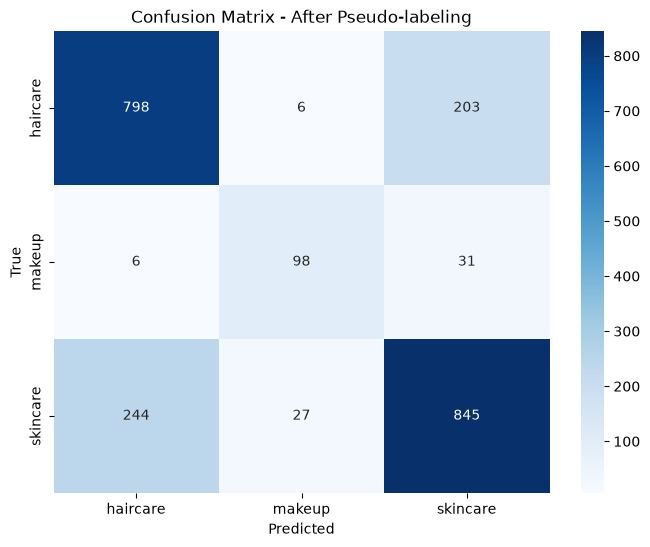

              precision    recall  f1-score   support

    haircare       0.76      0.79      0.78      1007
      makeup       0.75      0.73      0.74       135
    skincare       0.78      0.76      0.77      1116

    accuracy                           0.77      2258
   macro avg       0.76      0.76      0.76      2258
weighted avg       0.77      0.77      0.77      2258



In [18]:
model2.eval()
all_preds2 = []
all_labels2 = []
with torch.no_grad():
    for images, labels in tqdm(test_loader2, desc='Testing'):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model2(images)
        _, predicted = torch.max(outputs, 1)
        all_preds2.extend(predicted.cpu().numpy())
        all_labels2.extend(labels.cpu().numpy())
cm2 = confusion_matrix(all_labels2, all_preds2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=train_ds2.classes, yticklabels=train_ds2.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - After Pseudo-labeling')
plt.show()
print(classification_report(all_labels2, all_preds2, target_names=train_ds2.classes))

## 7. Comparison vs Phase 5 Keyword Baseline

Run the keyword-based classifier from `extraction.py` on the same test set
to compare accuracy.

In [19]:
import sys
sys.path.insert(0, str(Path.cwd().parent))

from app.services.extraction import CATEGORY_KEYWORDS

# Phase 5 keyword baseline accuracy on test set
kw_correct = 0
kw_total = 0

# We need product names from the test set — re-load from dataset with product_name
ds = datasets.load_dataset("openfoodfacts/product-database", split="beauty")
# Build lookup: code -> product_name
# ... (code to match test set samples back to product names)

# For now, placeholder:
# kw_accuracy = ...

print("ML Classifier Test Accuracy: {:.2f}%".format(100 * (np.array(all_preds) == np.array(all_labels)).mean()))
print("Keyword Baseline Test Accuracy: <fill in after comparison>")

NameError: name 'datasets' is not defined

## 8. Sample Predictions

In [ ]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[i]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()